In [6]:
import os
import math
import random
import h5py
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import EdgeConv, global_mean_pool, global_max_pool
from torch_geometric.utils import to_undirected

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [8]:
FILE_PATH = "quark-gluon_data-set_n139306.hdf5"

BATCH_SIZE = 4
EPOCHS = 20
LR = 5e-4
WEIGHT_DECAY = 1e-5
K_NEIGHBORS = 8

VAL_SIZE = 0.15
TEST_SIZE = 0.15

CACHE_FILE = f"qg_graph_dataset_k{K_NEIGHBORS}.pt"

DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: cpu


In [9]:
with h5py.File(FILE_PATH, "r") as f:
    print(list(f.keys()))
    X = f["X_jets"][:]
    y = f["y"][:]

print("X shape:", X.shape)
print("y shape:", y.shape)

y = np.asarray(y).reshape(-1).astype(np.int64)

['X_jets', 'm0', 'pt', 'y']
X shape: (139306, 125, 125, 3)
y shape: (139306,)


In [10]:
def to_hwc(image):
    image = np.asarray(image)

    if image.ndim == 2:
        return image[..., None]

    if image.ndim != 3:
        raise ValueError(f"Formato inesperado da imagem: {image.shape}")

    if image.shape[0] <= 6 and image.shape[1] > 6 and image.shape[2] > 6:
        image = np.transpose(image, (1, 2, 0))

    return image

In [11]:
def image_to_graph(image, label, k=8):
    image = to_hwc(image)
    H, W, C = image.shape

    activity = image.sum(axis=-1)
    ys, xs = np.nonzero(activity > 0)

    if len(xs) == 0:
        node_feats = np.zeros((1, C + 3), dtype=np.float32)
        pos = np.zeros((1, 2), dtype=np.float32)
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)

        return Data(
            x=torch.tensor(node_feats, dtype=torch.float),
            pos=torch.tensor(pos, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor(int(label), dtype=torch.long),
        )

    pixel_values = image[ys, xs, :].astype(np.float32)

    # normalização simples das intensidades do jet
    denom = np.sum(pixel_values) + 1e-12
    pixel_values = pixel_values / denom

    x_norm = xs.astype(np.float32) / max(W - 1, 1)
    y_norm = ys.astype(np.float32) / max(H - 1, 1)

    weights = pixel_values.sum(axis=1).astype(np.float32)
    wsum = np.sum(weights) + 1e-12

    cx = np.sum(xs * weights) / wsum
    cy = np.sum(ys * weights) / wsum

    r = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2).astype(np.float32)
    r_norm = r / (math.sqrt(H**2 + W**2) + 1e-12)

    node_feats = np.concatenate(
        [
            pixel_values,
            x_norm[:, None],
            y_norm[:, None],
            r_norm[:, None],
        ],
        axis=1,
    )

    pos = np.stack([x_norm, y_norm], axis=1).astype(np.float32)

    x_tensor = torch.tensor(node_feats, dtype=torch.float)
    pos_tensor = torch.tensor(pos, dtype=torch.float)

    n_nodes = x_tensor.size(0)

    if n_nodes == 1:
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)
    else:
        k_eff = min(k, n_nodes - 1)

        nbrs = NearestNeighbors(n_neighbors=k_eff + 1, algorithm="auto")
        nbrs.fit(pos)
        _, indices = nbrs.kneighbors(pos)

        edges = []
        for i in range(n_nodes):
            for j in indices[i][1:]:
                edges.append([i, j])

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_index = to_undirected(edge_index, num_nodes=n_nodes)

    return Data(
        x=x_tensor,
        pos=pos_tensor,
        edge_index=edge_index,
        y=torch.tensor(int(label), dtype=torch.long),
    )

In [13]:
def build_graph_dataset(X, y, k=8, cache_file=None):
    if cache_file is not None and os.path.exists(cache_file):
        print(f"Loading cached graphs from: {cache_file}")
        return torch.load(cache_file, weights_only=False)

    graphs = []
    for i in tqdm(range(len(X)), desc="Converting images to graphs"):
        graphs.append(image_to_graph(X[i], y[i], k=k))

    if cache_file is not None:
        torch.save(graphs, cache_file)
        print(f"Saved graph dataset to: {cache_file}")

    return graphs

graphs = build_graph_dataset(X, y, k=K_NEIGHBORS, cache_file=CACHE_FILE)
print("Total graphs:", len(graphs))
print("Example graph:", graphs[0])
print("Node feature dimension:", graphs[0].x.shape[1])

Loading cached graphs from: qg_graph_dataset_k8.pt
Total graphs: 139306
Example graph: Data(x=[884, 6], edge_index=[2, 8616], y=0, pos=[884, 2])
Node feature dimension: 6


In [14]:
indices = np.arange(len(graphs))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=VAL_SIZE + TEST_SIZE,
    random_state=42,
    stratify=y,
)

temp_y = y[temp_idx]
val_relative, test_relative = train_test_split(
    np.arange(len(temp_idx)),
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=42,
    stratify=temp_y,
)

val_idx = temp_idx[val_relative]
test_idx = temp_idx[test_relative]

train_graphs = [graphs[i] for i in train_idx]
val_graphs   = [graphs[i] for i in val_idx]
test_graphs  = [graphs[i] for i in test_idx]

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train: 97514 | Val: 20896 | Test: 20896


In [15]:
class JetEdgeConvNet(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_classes=2):
        super().__init__()

        self.conv1 = EdgeConv(
            nn.Sequential(
                nn.Linear(2 * in_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU(),
            ),
            aggr="max"
        )
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = EdgeConv(
            nn.Sequential(
                nn.Linear(2 * hidden_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU(),
            ),
            aggr="max"
        )
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_channels, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        out = self.classifier(x)
        return out


in_channels = graphs[0].x.shape[1]
model = JetEdgeConvNet(in_channels=in_channels).to(DEVICE)

# peso de classe
train_y = y[train_idx]
class_counts = np.bincount(train_y, minlength=2)
class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Class counts (train):", class_counts)
print("Class weights:", class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(weight=class_weights)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

Class counts (train): [48757 48757]
Class weights: tensor([1., 1.])


In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

    return total_loss / total_graphs


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_y_true = []
    all_y_pred = []
    all_y_prob = []

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch.x, batch.edge_index, batch.batch)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        all_y_true.append(batch.y.cpu().numpy())
        all_y_pred.append(preds.cpu().numpy())
        all_y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)
    y_prob = np.concatenate(all_y_prob)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")

    pos_rate = y_pred.mean()

    return {
        "accuracy": acc,
        "f1": f1,
        "auc": auc,
        "pos_rate": pos_rate,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

In [17]:
import gc

best_val_auc = -1.0
best_model_path = "best_qg_gnn.pt"
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)

    val_metrics = evaluate(model, val_loader, DEVICE)
    val_acc = val_metrics["accuracy"]
    val_f1 = val_metrics["f1"]
    val_auc = val_metrics["auc"]
    val_pos_rate = val_metrics["pos_rate"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_auc": val_auc,
        "val_pos_rate": val_pos_rate,
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"pred_pos_rate={val_pos_rate:.4f}"
    )

    if not math.isnan(val_auc):
        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), best_model_path)

    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

print(f"\nBest validation AUC: {best_val_auc:.4f}")

Epoch 01/20 | train_loss=0.6082 | val_acc=0.7015 | val_f1=0.6925 | val_auc=0.7663 | pred_pos_rate=0.4708
Epoch 02/20 | train_loss=0.5912 | val_acc=0.6998 | val_f1=0.6841 | val_auc=0.7664 | pred_pos_rate=0.4501
Epoch 03/20 | train_loss=0.5883 | val_acc=0.6880 | val_f1=0.7230 | val_auc=0.7682 | pred_pos_rate=0.6266
Epoch 04/20 | train_loss=0.5857 | val_acc=0.6992 | val_f1=0.7221 | val_auc=0.7722 | pred_pos_rate=0.5824
Epoch 05/20 | train_loss=0.5838 | val_acc=0.7059 | val_f1=0.7155 | val_auc=0.7739 | pred_pos_rate=0.5336
Epoch 06/20 | train_loss=0.5817 | val_acc=0.7050 | val_f1=0.6844 | val_auc=0.7755 | pred_pos_rate=0.4350
Epoch 07/20 | train_loss=0.5795 | val_acc=0.7101 | val_f1=0.7058 | val_auc=0.7764 | pred_pos_rate=0.4853
Epoch 08/20 | train_loss=0.5789 | val_acc=0.7118 | val_f1=0.7051 | val_auc=0.7790 | pred_pos_rate=0.4774
Epoch 09/20 | train_loss=0.5782 | val_acc=0.7060 | val_f1=0.6834 | val_auc=0.7779 | pred_pos_rate=0.4286
Epoch 10/20 | train_loss=0.5769 | val_acc=0.7116 | val_

In [18]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_metrics = evaluate(model, test_loader, DEVICE)

print("\n===== TEST RESULTS =====")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f"ROC AUC : {test_metrics['auc']:.4f}")
print("\nClassification Report:")
print(classification_report(test_metrics["y_true"], test_metrics["y_pred"], digits=4))


===== TEST RESULTS =====
Accuracy: 0.7064
F1-score: 0.7369
ROC AUC : 0.7849

Classification Report:
              precision    recall  f1-score   support

           0     0.7687    0.5904    0.6678     10448
           1     0.6675    0.8224    0.7369     10448

    accuracy                         0.7064     20896
   macro avg     0.7181    0.7064    0.7023     20896
weighted avg     0.7181    0.7064    0.7023     20896



In [19]:
def inspect_graph(data):
    print("Graph summary:")
    print(data)
    print("Number of nodes:", data.num_nodes)
    print("Number of edges:", data.num_edges)
    print("Node feature shape:", data.x.shape)
    print("Position shape:", data.pos.shape)
    print("Label:", data.y.item())

# Exemplo
inspect_graph(graphs[0])

Graph summary:
Data(x=[884, 6], edge_index=[2, 8616], y=0, pos=[884, 2])
Number of nodes: 884
Number of edges: 8616
Node feature shape: torch.Size([884, 6])
Position shape: torch.Size([884, 2])
Label: 0


In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_graph(data):

    G = to_networkx(data, to_undirected=True)

    pos = {i: data.pos[i].cpu().numpy() for i in range(data.num_nodes)}

    plt.figure(figsize=(6,6))
    nx.draw(
        G,
        pos,
        node_size = data.x[:,0] * 2000,
        node_color="red",
        edge_color="gray",
        alpha=0.7
    )

    plt.title("Jet Graph Representation")
    plt.show()

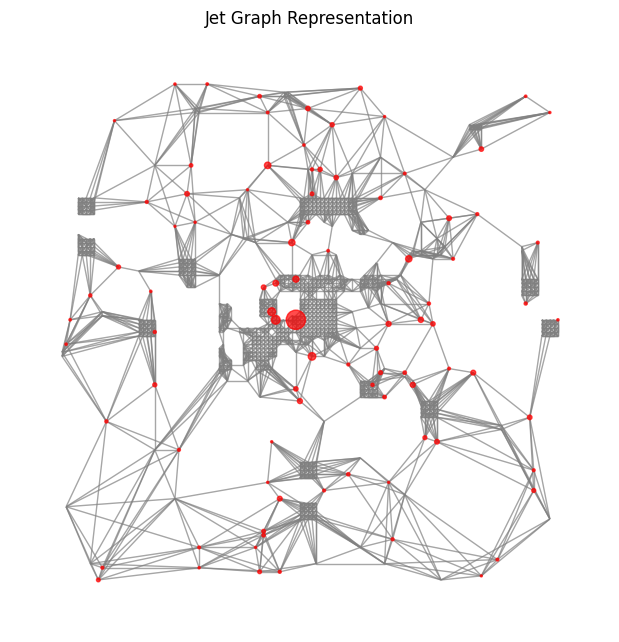

In [25]:
visualize_graph(graphs[0])